# Universal Grammar Generative Model

In [38]:
INSTALL = true

if INSTALL
    using Pkg
    Pkg.add("StatsPlots"); using StatsPlots
    Pkg.activate("psyc261")
    Pkg.add(["JLD2", "Distributions", "ProgressMeter", "Parameters", 
            "Random", "Gen", "Plots", "PyCall", "Conda", "JSON3"])
end

   Resolving package versions...
   Installed WoodburyMatrices ─ v0.5.6
    Updating `~/Algorithms-of-the-Mind/aom/notebooks/psyc261/Project.toml`
  [f3b207a7] + StatsPlots v0.15.6
    Updating `~/Algorithms-of-the-Mind/aom/notebooks/psyc261/Manifest.toml`
  [621f4979] + AbstractFFTs v1.5.0
  [79e6a3ab] + Adapt v3.7.1
  [7d9fca2a] + Arpack v0.5.4
  [13072b0f] + AxisAlgorithms v1.0.1
  [aaaa29a8] + Clustering v0.15.5
  [e2d170a0] + DataValueInterfaces v1.0.0
  [b4f34e82] + Distances v0.10.10
  [7a1cc6ca] + FFTW v1.7.1
⌅ [a98d9a8b] + Interpolations v0.14.7
  [82899510] + IteratorInterfaceExtensions v1.0.0
  [5ab0869b] + KernelDensity v0.6.7
  [6f286f6a] + MultivariateStats v0.10.2
  [b8a86587] + NearestNeighbors v0.4.13
  [510215fc] + Observables v0.5.5
  [6fe1bfb0] + OffsetArrays v1.12.10
  [c84ed2f1] + Ratios v0.4.5
  [91c51154] + SentinelArrays v1.4.1
  [f3b207a7] + StatsPlots v0.15.6
  [ab02a1b2] + TableOperations v1.2.0
  [3783bdb8] + TableTraits v1.0.1
  [bd369af6] + Tables v1.11.1

In [2]:
include("../src/ug_model.jl")
using .UGmodel

In [39]:
using Pkg
Pkg.activate("psyc261")
using JLD2
using Distributions
using ProgressMeter
using Parameters
using Random
using StatsPlots
using Gen, Plots
using PyCall
np = pyimport("numpy")

  Activating project at `~/Algorithms-of-the-Mind/aom/notebooks/psyc261`


PyObject <module 'numpy' from '/home/psyc2610_jdp69/.local/lib/python3.11/site-packages/numpy/__init__.py'>

## Generative Model

In [4]:
const NOUNS = UGmodel.LEXICON.nouns
const VERBS_TRANS = UGmodel.LEXICON.verbs_trans
const VERBS_INTR = UGmodel.LEXICON.verbs_intr
const ADJECTIVES = UGmodel.LEXICON.adjectives
const WH_WORD = UGmodel.LEXICON.wh_word

"what"

In [5]:
# Creating fixed size vocabulary
const VOCAB = unique(vcat(["PAD", WH_WORD], NOUNS, VERBS_TRANS, VERBS_INTR, ADJECTIVES))
const VOCAB_SIZE = length(VOCAB)
const WORD_TO_IDX = Dict(w => i for (i,w) in enumerate(VOCAB))
const MAX_SENT_LEN = 6

6

In [6]:
# Noise constant to account for misunderstandings, slip of the tongue etc.
# Generates ungrammatical sentences
const NOISE_PROB = 0.1

0.1

In [7]:
function emission_probs(target_idx::Int; V::Int = VOCAB_SIZE, epsilon::Float64 = 0.05)
    @assert 0 < epsilon < 1
    probs = fill(epsilon / (V-1), V)
    probs[target_idx] = 1.0 -epsilon

    return probs

end

emission_probs (generic function with 1 method)

In [8]:
@gen function corpus_model(num_sentences::Int)
    # === Universal Grammar paramaters (theta) ===
    # Head direction: 1 = Verb-Object (VO), 0 = Object-Verb(OV)
    hd = @trace(bernoulli(0.5), :head_direction)

    # Subject drop: 1 = subject may be dropped, 0 = subject always present
    sd = @trace(bernoulli(0.5), :subject_drop)

    # Adjective order: 1 = Adjective-Noun (AN), 0 = Noun-Adjective (NA)
    ao = @trace(bernoulli(0.5), :adj_order)

    # Wh-fronting in question: 1 = wh-word at front, 0 = in-situ
    wh = @trace(bernoulli(0.5), :wh_fronting)
    
    sentences = Vector{Vector{String}}(undef, num_sentences)

    for i in 1:num_sentences
        # Utterance type: 1 = transitive declarative, 2 = intransitive, 3 = transitive question
        utt_type = @trace(categorical([0.4, 0.3, 0.3]), (:utt_type, i))

        # Sample lexical items
        subj_idx = @trace(categorical(fill(1/length(NOUNS), length(NOUNS))), (:subj, i))
        obj_idx = @trace(categorical(fill(1/length(NOUNS), length(NOUNS))), (:obj, i))
        adj_idx = @trace(categorical(fill(1/length(ADJECTIVES), length(ADJECTIVES))), (:adj, i))

        if utt_type == 1 || utt_type == 3
            v_idx = @trace(categorical(fill(1/length(VERBS_TRANS), length(VERBS_TRANS))), (:v_trans, i))
            verb = VERBS_TRANS[v_idx]
        else
            v_idx = @trace(categorical(fill(1/length(VERBS_INTR), length(VERBS_INTR))), (:v_intr, i))
            verb = VERBS_INTR[v_idx]
        end

        subj = NOUNS[subj_idx]
        obj = NOUNS[obj_idx]
        adj = ADJECTIVES[adj_idx]

        # Add adjective order error
        ao_slip = @trace(bernoulli(NOISE_PROB), (:ao_slip, i))
        effective_ao = ao_slip ? !ao : ao
        
        # Build NP for subject and object, respecting adjective order and taking error into account
        function make_np(noun::String, adj::String, order_rule::Bool)
            if order_rule == 1
                return [adj, noun] # Adj N
            else
                return [noun, adj] # N Adj
            end
        end

        subj_np = make_np(subj, adj, effective_ao)
        obj_np = make_np(obj, adj, effective_ao)

        # Add head direction error
        hd_slip = @trace(bernoulli(NOISE_PROB), (:hd_slip, i))
        effective_hd = hd_slip ? !hd : hd

        # Base clause word order for transitive
        vp = Vector{String}()
        if utt_type == 1 || utt_type == 3
            # Verb-Object vs. Object-Verb in the VP
            vp = (effective_hd == 1) ? vcat([verb], obj_np) : vcat(obj_np, [verb])
        else
            # Intransitive: just the verb
            vp = [verb]
        end

        # Add subject drop error
        sd_slip = @trace(bernoulli(NOISE_PROB), (:sd_slip, i))
        effective_sd = sd_slip ? !sd : sd

        # Drop subject if SD = 1
        drop_subj = (effective_sd == 1) ? @trace(bernoulli(0.5), (:drop_subj, i)) : 0

        clause = Vector{String}()

        if drop_subj == 0
            append!(clause, subj_np)
        end
        
        append!(clause, vp)

        # Handle questions
        if utt_type == 3
            wh_slip = @trace(bernoulli(NOISE_PROB), (:wh_slip, i))
            effective_wh = wh_slip ? !wh : wh
            
            if effective_wh == 1
                # wh-fronting
                clause = vcat([WH_WORD], clause)
            else
                # wh in-situ (append at the end)
                push!(clause, WH_WORD)
            end
        end

        sentences[i] = clause

        for pos in 1:MAX_SENT_LEN
            word = pos <= length(clause) ? clause[pos] : "PAD"
            vocab_idx = WORD_TO_IDX[word]
            probs = emission_probs(vocab_idx; V=VOCAB_SIZE, epsilon = NOISE_PROB * 0.5)
            @trace(categorical(probs), (:token, i, pos))
        end
    end

    return sentences
end

DynamicDSLFunction{Any}(Dict{Symbol, Any}(), Dict{Symbol, Any}(), Type[Int64], false, Union{Nothing, Some{Any}}[nothing], var"##corpus_model#292", Bool[0], false)

In [9]:
trace = simulate(corpus_model, (10,))
sentences = get_retval(trace)
theta = (
    hd = trace[:head_direction],
    sd = trace[:subject_drop],
    ao = trace[:adj_order],
    wh = trace[:wh_fronting]
)
theta

(hd = true, sd = false, ao = true, wh = false)

## Neural Network

In [10]:
# Neural net params
const NUM_SENTS_TRAIN = 10
const INPUT_DIM = VOCAB_SIZE * MAX_SENT_LEN * NUM_SENTS_TRAIN
H = 128

128

In [11]:
mutable struct NeuralNetParams
    W1::Matrix{Float64}  
    b1::Vector{Float64}  
    W2::Matrix{Float64}  
    b2::Vector{Float64}  
end

### Encoding the sentences

In [12]:
# Convert sentences into a flattened one hot encoded vector
function encode_corpus(sentences::Vector{Vector{String}})
    encoded = zeros(Float64, INPUT_DIM)

    cursor = 0
    for i in 1:NUM_SENTS_TRAIN
        if i > length(sentences) break end

        sent = sentences[i]
        for j in 1:MAX_SENT_LEN
            word = j <= length(sent) ? sent[j] : "PAD"

            vocab_idx = WORD_TO_IDX[word]

            encoded[cursor * VOCAB_SIZE + vocab_idx] = 1.0
            cursor += 1
        end
    end

    return encoded
end

encode_corpus (generic function with 1 method)

### Creating the innate solver neural network (Variational Approximation)

In [13]:
σ(x) = tanh.(x)
sigmoid(x) = 1.0 ./ (1.0 .+ exp.(-x))

@gen function innate_solver(input_vector::Vector{Float64})
    @param W1::Matrix{Float64}
    @param b1::Vector{Float64}
    @param W2::Matrix{Float64}
    @param b2::Vector{Float64}

    hidden_layer = σ(W1 * input_vector + b1)
    output = W2 * hidden_layer + b2

    probs = sigmoid(output)

    for i in 1:4
        @trace(Gen.bernoulli(probs[i]), (:param, i))
    end
    
    return probs
end

init_weight(out, inc) = randn(out, inc) * 0.01
init_param!(innate_solver, :W1, init_weight(H, INPUT_DIM))
init_param!(innate_solver, :b1, zeros(H))
init_param!(innate_solver, :W2, init_weight(4, H))
init_param!(innate_solver, :b2, zeros(4))

4-element Vector{Float64}:
 0.0
 0.0
 0.0
 0.0

### Generating synthetic languages from the GM

In [14]:
function supervised_training_batch_generator()
    tr = simulate(corpus_model, (NUM_SENTS_TRAIN,))
    sentences = get_retval(tr)

    input_vec = encode_corpus(sentences)

    constraints = Gen.choicemap()
    constraints[(:param, 1)] = tr[:head_direction]
    constraints[(:param, 2)] = tr[:subject_drop]
    constraints[(:param, 3)] = tr[:adj_order]
    constraints[(:param, 4)] = tr[:wh_fronting]

    return ((input_vec,), constraints)
end

supervised_training_batch_generator (generic function with 1 method)

### Training the innate solver

Epoch 1: avg loss = 1.5873
Epoch 10: avg loss = 1.5362
Epoch 20: avg loss = 1.3716
Epoch 30: avg loss = 1.3756
Epoch 40: avg loss = 1.2103
Epoch 50: avg loss = 1.3062
Epoch 60: avg loss = 1.2552
Epoch 70: avg loss = 1.1647
Epoch 80: avg loss = 1.0936
Epoch 90: avg loss = 1.078
Epoch 100: avg loss = 1.1501
Epoch 110: avg loss = 1.0903
Epoch 120: avg loss = 0.9526
Epoch 130: avg loss = 0.8684
Epoch 140: avg loss = 0.927
Epoch 150: avg loss = 0.8283
Epoch 160: avg loss = 0.9451
Epoch 170: avg loss = 0.8291
Epoch 180: avg loss = 0.8549
Epoch 190: avg loss = 0.7853
Epoch 200: avg loss = 0.7586
Epoch 210: avg loss = 0.6289
Epoch 220: avg loss = 0.6496
Epoch 230: avg loss = 0.759
Epoch 240: avg loss = 0.6613
Epoch 250: avg loss = 0.5812
Epoch 260: avg loss = 0.6199
Epoch 270: avg loss = 0.5745
Epoch 280: avg loss = 0.5711
Epoch 290: avg loss = 0.5256
Epoch 300: avg loss = 0.6237
Epoch 310: avg loss = 0.7703
Epoch 320: avg loss = 0.5121
Epoch 330: avg loss = 0.5594
Epoch 340: avg loss = 0.5367

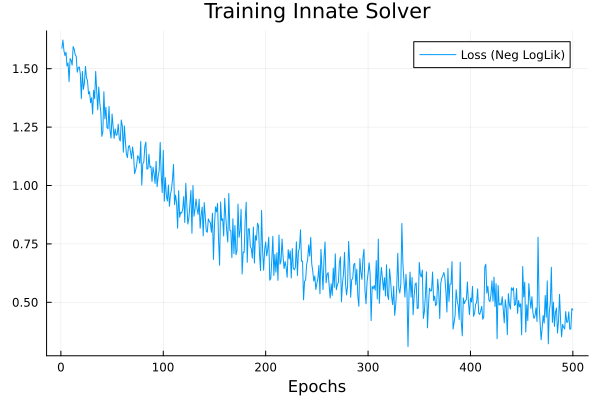

In [16]:
update = Gen.ParamUpdate(Gen.FixedStepGradientDescent(0.001), innate_solver)

NUM_EPOCHS = 500
EPOCH_SIZE = 50

TRAIN = true

if TRAIN
    losses = Float64[]
    
    for epoch in 1:NUM_EPOCHS
        epoch_loss = 0.0
        
        for i in 1:EPOCH_SIZE
            (args, constraints) = supervised_training_batch_generator()
            (trace, weight) = generate(innate_solver, args, constraints)
            
            Gen.accumulate_param_gradients!(trace)
            
            epoch_loss += -get_score(trace)
        end
        
        Gen.apply!(update)
        
        avg_loss = epoch_loss / EPOCH_SIZE
        push!(losses, avg_loss)
        
        if epoch == 1 || epoch % 10 == 0
            println("Epoch $epoch: avg loss = $(round(avg_loss, digits=4))")
        end
    end

    plot(losses, label = "Loss (Neg LogLik)", xlabel = "Epochs", title = "Training Innate Solver")
end

## Comparison Innate Solver vs Naive Learner

In [25]:
function predict_nn(input_vec::Vector{Float64})
    W1 = get_param(innate_solver, :W1)
    b1 = get_param(innate_solver, :b1)
    W2 = get_param(innate_solver, :W2)
    b2 = get_param(innate_solver, :b2)

    hidden = σ(W1 * input_vec + b1)
    output = W2 * hidden + b2
    probs = sigmoid(output)

    preds = (
        hd = probs[1] > 0.5,
        sd = probs[2] > 0.5,
        ao = probs[3] > 0.5,
        wh = probs[4] > 0.5,
    )

    return preds, probs
end

predict_nn (generic function with 1 method)

In [19]:
# MH update on the 4 parameters
function mh_step(tr)
    tr, _ = mh(tr, select(:head_direction))
    tr, _ = mh(tr, select(:subject_drop))
    tr, _ = mh(tr, select(:adj_order))
    tr, _ = mh(tr, select(:wh_fronting))
    return tr
end

mh_step (generic function with 1 method)

In [20]:
function is_correct(tr)
    return tr[:head_direction] == target_theta.hd &&
           tr[:subject_drop] == target_theta.sd &&
           tr[:adj_order] == target_theta.ao &&
           tr[:wh_fronting] == target_theta.wh
end

is_correct (generic function with 1 method)

In [21]:
# Define the ground truth constraints. This is set to be somewhat English-like
target_theta = (hd=true, sd=false, ao=true, wh=true)

target_constraints = Gen.choicemap()
target_constraints[:head_direction] = target_theta.hd
target_constraints[:subject_drop] = target_theta.sd
target_constraints[:adj_order] = target_theta.ao
target_constraints[:wh_fronting] = target_theta.wh

# Generate data with the constraints
tr_target, _ = generate(corpus_model, (NUM_SENTS_TRAIN,), target_constraints)
observed_sentences = get_retval(tr_target)
observed_input_vec = encode_corpus(observed_sentences)

# Create the observation constraints
# Note that this constrains the trace to match the observed tokens to make inference more tractable
# Since we're observing the capability of inferring the underlying parameters, guessing the tokens is not relevant to the task
obs_map = Gen.choicemap()
for i in 1:NUM_SENTS_TRAIN
    obs_map[(:utt_type, i)] = tr_target[(:utt_type, i)]
    obs_map[(:subj, i)] = tr_target[(:subj, i)]
    obs_map[(:obj, i)] = tr_target[(:obj, i)]
    obs_map[(:adj, i)] = tr_target[(:adj, i)]

    if tr_target[(:utt_type, i)] == 1 || tr_target[(:utt_type, i)] == 3
         obs_map[(:v_trans, i)] = tr_target[(:v_trans, i)]
    else
         obs_map[(:v_intr, i)] = tr_target[(:v_intr, i)]
    end

    for j in 1:MAX_SENT_LEN
        obs_map[(:token, i, j)] = tr_target[(:token, i, j)]
    end
end

### Naive Learner with random initialization

In [23]:
naive_trace, _ = generate(corpus_model, (NUM_SENTS_TRAIN,), obs_map)

naive_acc = Float64[]
push!(naive_acc, is_correct(naive_trace) ? 1.0 : 0.0)

for i in 1:500
    global naive_trace = mh_step(naive_trace)
    push!(naive_acc, is_correct(naive_trace) ? 1.0 : 0.0)
end

### Guided Learner

In [27]:
# Get the guided guess from the neural network
nn_preds, nn_probs = predict_nn(observed_input_vec)

# Get the initial observation constraints
guided_init_map = deepcopy(obs_map)

# Add the neural network predictions as initial values
guided_init_map[:head_direction] = nn_preds.hd
guided_init_map[:subject_drop] = nn_preds.sd
guided_init_map[:adj_order] = nn_preds.ao
guided_init_map[:wh_fronting] = nn_preds.wh

guided_trace, _ = generate(corpus_model, (NUM_SENTS_TRAIN,), guided_init_map)

guided_acc = Float64[]
push!(guided_acc, is_correct(guided_trace) ? 1.0 : 0.0)

for i in 1:500
    global guided_trace = mh_step(guided_trace)
    push!(guided_acc, is_correct(guided_trace) ? 1.0 : 0.0)
end

## Results Visualization

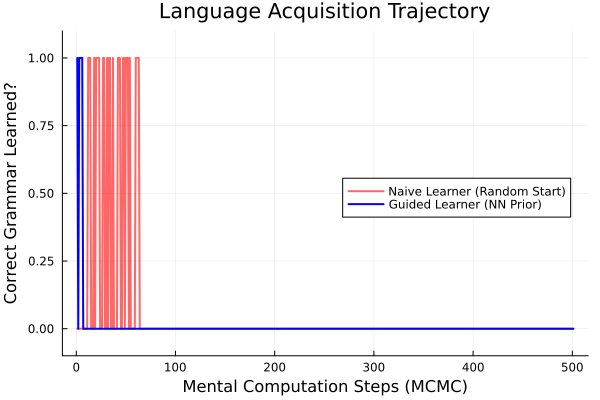

In [29]:
p_results = plot(
    title="Language Acquisition Trajectory", 
    xlabel="Mental Computation Steps (MCMC)", 
    ylabel="Correct Grammar Learned?",
    legend=:right,
    ylim=(-0.1, 1.1)
)

plot!(p_results, naive_acc, label="Naive Learner (Random Start)", color=:red, alpha=0.6, linewidth=2)
plot!(p_results, guided_acc, label="Guided Learner (NN Prior)", color=:blue, linewidth=2)

display(p_results)

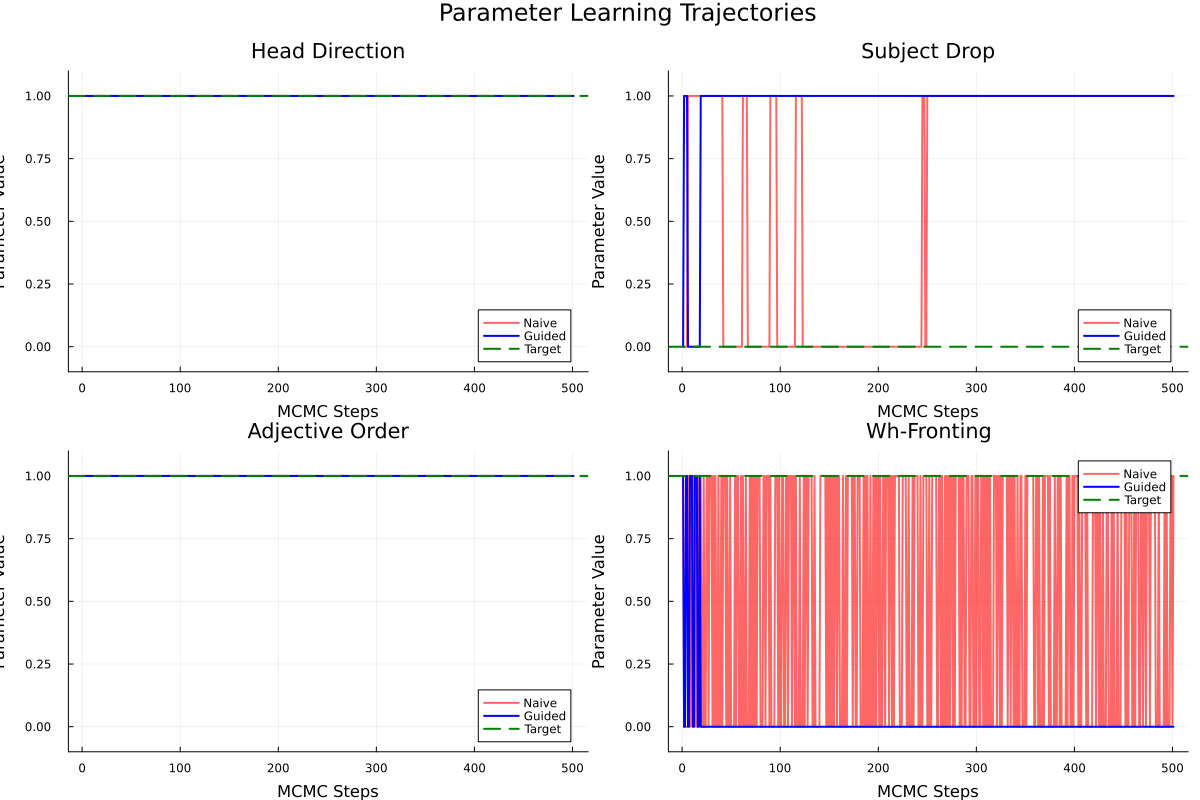

In [31]:
function track_parameters(trace, n_steps)
    param_history = Dict(
        :hd => Bool[],
        :sd => Bool[],
        :ao => Bool[],
        :wh => Bool[]
    )
    
    for step in 0:n_steps
        push!(param_history[:hd], trace[:head_direction])
        push!(param_history[:sd], trace[:subject_drop])
        push!(param_history[:ao], trace[:adj_order])
        push!(param_history[:wh], trace[:wh_fronting])
        
        if step < n_steps
            trace = mh_step(trace)
        end
    end
    
    return param_history, trace
end

# Run tracking for both learners
naive_trace, _ = generate(corpus_model, (NUM_SENTS_TRAIN,), obs_map)
naive_params, naive_final = track_parameters(naive_trace, 500)

nn_preds, nn_probs = predict_nn(observed_input_vec)
guided_init_map = deepcopy(obs_map)
guided_init_map[:head_direction] = nn_preds.hd
guided_init_map[:subject_drop] = nn_preds.sd
guided_init_map[:adj_order] = nn_preds.ao
guided_init_map[:wh_fronting] = nn_preds.wh
guided_trace, _ = generate(corpus_model, (NUM_SENTS_TRAIN,), guided_init_map)
guided_params, guided_final = track_parameters(guided_trace, 500)

# Visualization
p = plot(layout=(2,2), size=(1200, 800), 
         plot_title="Parameter Learning Trajectories")

param_names = [:hd => "Head Direction", :sd => "Subject Drop", 
               :ao => "Adjective Order", :wh => "Wh-Fronting"]

for (i, (key, name)) in enumerate(param_names)
    plot!(p[i], 
          Float64.(naive_params[key]), 
          label="Naive", 
          color=:red, 
          alpha=0.6,
          linewidth=2,
          title=name,
          xlabel="MCMC Steps",
          ylabel="Parameter Value",
          ylim=(-0.1, 1.1))
    
    plot!(p[i],
          Float64.(guided_params[key]),
          label="Guided",
          color=:blue,
          linewidth=2)
    
    # Add target line
    target_val = getfield(target_theta, key)
    hline!(p[i], [Float64(target_val)], 
           label="Target", 
           color=:green, 
           linestyle=:dash,
           linewidth=2)
end

display(p)

In [32]:
function visualize_nn_confidence(probs, preds, target)
    param_labels = ["Head Direction", "Subject Drop", "Adj Order", "Wh-Fronting"]
    
    # Create data matrix: [probability, is_correct]
    data = zeros(4, 3)
    for (i, key) in enumerate([:hd, :sd, :ao, :wh])
        data[i, 1] = probs[i]  # Confidence
        data[i, 2] = Float64(getfield(preds, key))  # Prediction
        data[i, 3] = Float64(getfield(target, key))  # Target
    end
    
    p = plot(layout=(1,3), size=(1200, 400))
    
    # Confidence bars
    bar!(p[1], param_labels, probs, 
         title="NN Confidence", 
         ylabel="Probability",
         legend=false,
         xrotation=45,
         color=:lightblue)
    hline!(p[1], [0.5], linestyle=:dash, color=:red, label="Threshold")
    
    # Prediction vs Target
    pred_vals = [Float64(getfield(preds, k)) for k in [:hd, :sd, :ao, :wh]]
    target_vals = [Float64(getfield(target, k)) for k in [:hd, :sd, :ao, :wh]]
    
    groupedbar!(p[2], 
                hcat(pred_vals, target_vals),
                labels=["NN Prediction" "Target"],
                title="Prediction vs Target",
                ylabel="Value",
                xticks=(1:4, param_labels),
                xrotation=45,
                color=[:blue :green])
    
    # Correctness
    correct = [Float64(getfield(preds, k) == getfield(target, k)) for k in [:hd, :sd, :ao, :wh]]
    bar!(p[3], param_labels, correct,
         title="Correctness",
         ylabel="Correct?",
         legend=false,
         xrotation=45,
         color=ifelse.(correct .== 1.0, :green, :red),
         ylim=(0, 1.2))
    
    display(p)
end

visualize_nn_confidence(nn_probs, nn_preds, target_theta)

LoadError: UndefVarError: `groupedbar!` not defined

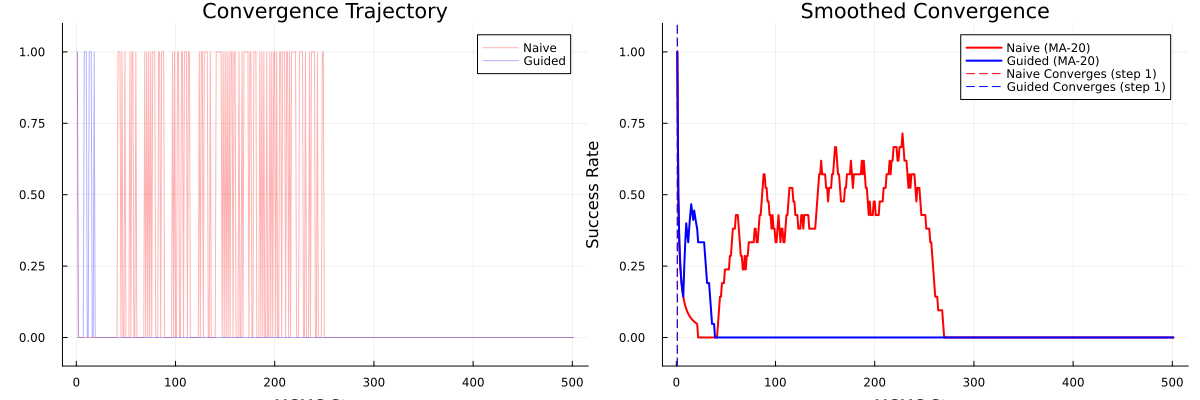

Naive learner converged at step: 1
Guided learner converged at step: 1
Speedup: 1.0x faster


In [34]:
function compute_convergence_metrics(param_history, target)
    n_steps = length(param_history[:hd])
    cumulative_correct = zeros(n_steps)
    
    for step in 1:n_steps
        all_correct = (param_history[:hd][step] == target.hd &&
                      param_history[:sd][step] == target.sd &&
                      param_history[:ao][step] == target.ao &&
                      param_history[:wh][step] == target.wh)
        cumulative_correct[step] = all_correct ? 1.0 : 0.0
    end
    
    # Find first convergence
    first_correct = findfirst(x -> x == 1.0, cumulative_correct)
    convergence_step = first_correct === nothing ? n_steps : first_correct
    
    # Compute moving average
    window = 20
    moving_avg = [mean(cumulative_correct[max(1, i-window):i]) for i in 1:n_steps]
    
    return cumulative_correct, moving_avg, convergence_step
end

naive_correct, naive_mavg, naive_conv = compute_convergence_metrics(naive_params, target_theta)
guided_correct, guided_mavg, guided_conv = compute_convergence_metrics(guided_params, target_theta)

p = plot(layout=(1,2), size=(1200, 400))

# Raw convergence
plot!(p[1], naive_correct,
      label="Naive",
      color=:red,
      alpha=0.3,
      title="Convergence Trajectory",
      xlabel="MCMC Steps",
      ylabel="All Parameters Correct?",
      ylim=(-0.1, 1.1))
plot!(p[1], guided_correct,
      label="Guided",
      color=:blue,
      alpha=0.3)

# Moving average
plot!(p[2], naive_mavg,
      label="Naive (MA-20)",
      color=:red,
      linewidth=2,
      title="Smoothed Convergence",
      xlabel="MCMC Steps",
      ylabel="Success Rate",
      ylim=(-0.1, 1.1))
plot!(p[2], guided_mavg,
      label="Guided (MA-20)",
      color=:blue,
      linewidth=2)

# Add convergence markers
vline!(p[2], [naive_conv], 
       label="Naive Converges (step $naive_conv)",
       color=:red,
       linestyle=:dash)
vline!(p[2], [guided_conv],
       label="Guided Converges (step $guided_conv)",
       color=:blue,
       linestyle=:dash)

display(p)
println("Naive learner converged at step: $naive_conv")
println("Guided learner converged at step: $guided_conv")
println("Speedup: $(round(naive_conv / guided_conv, digits=2))x faster")

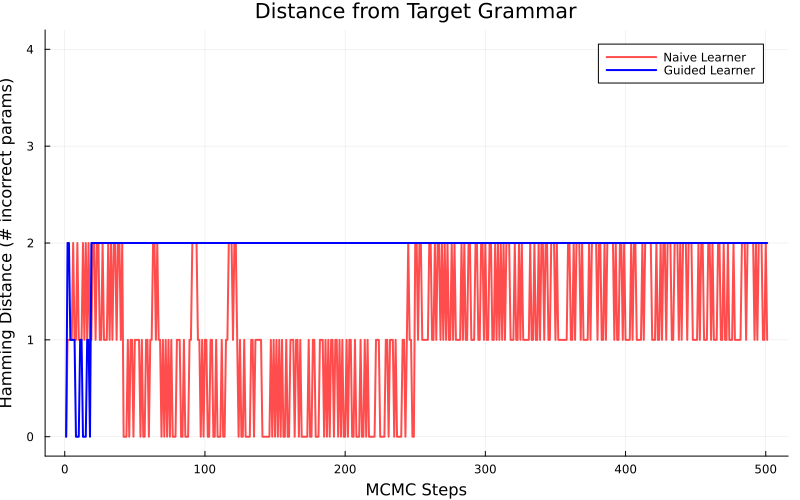

In [35]:
function hamming_distance(params, target, step)
    hd_match = params[:hd][step] == target.hd
    sd_match = params[:sd][step] == target.sd
    ao_match = params[:ao][step] == target.ao
    wh_match = params[:wh][step] == target.wh
    
    return 4 - sum([hd_match, sd_match, ao_match, wh_match])
end

naive_dist = [hamming_distance(naive_params, target_theta, i) for i in 1:501]
guided_dist = [hamming_distance(guided_params, target_theta, i) for i in 1:501]

p = plot(size=(800, 500))
plot!(naive_dist,
      label="Naive Learner",
      color=:red,
      linewidth=2,
      alpha=0.7,
      title="Distance from Target Grammar",
      xlabel="MCMC Steps",
      ylabel="Hamming Distance (# incorrect params)",
      ylim=(-0.2, 4.2))
plot!(guided_dist,
      label="Guided Learner",
      color=:blue,
      linewidth=2)

display(p)

Running 20 trials...


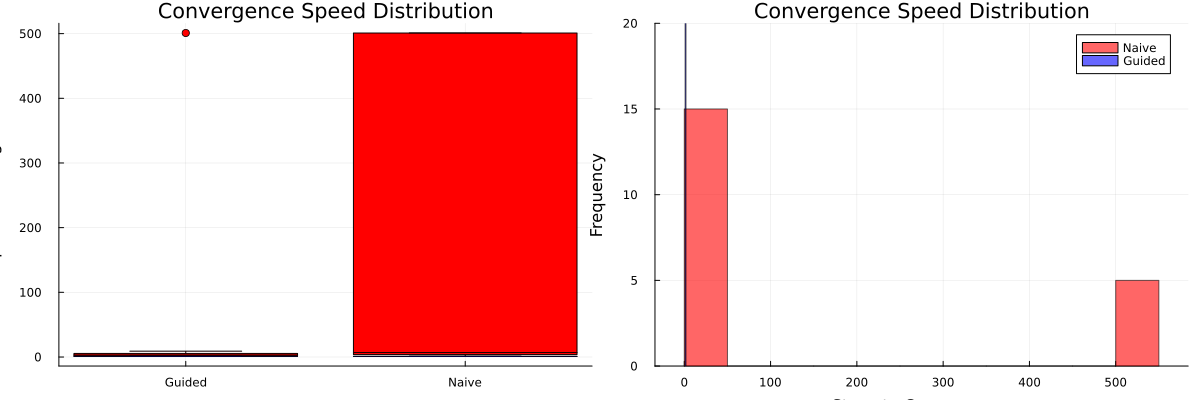


Statistics:
Naive - Mean: 128.2, Std: 220.9
Guided - Mean: 1.0, Std: 0.0
Average speedup: 128.15x


In [40]:
function run_comparison_trial()
    # Naive learner
    naive_trace, _ = generate(corpus_model, (NUM_SENTS_TRAIN,), obs_map)
    naive_params, _ = track_parameters(naive_trace, 500)
    _, _, naive_conv = compute_convergence_metrics(naive_params, target_theta)
    
    # Guided learner
    nn_preds, _ = predict_nn(observed_input_vec)
    guided_init_map = deepcopy(obs_map)
    guided_init_map[:head_direction] = nn_preds.hd
    guided_init_map[:subject_drop] = nn_preds.sd
    guided_init_map[:adj_order] = nn_preds.ao
    guided_init_map[:wh_fronting] = nn_preds.wh
    guided_trace, _ = generate(corpus_model, (NUM_SENTS_TRAIN,), guided_init_map)
    guided_params, _ = track_parameters(guided_trace, 500)
    _, _, guided_conv = compute_convergence_metrics(guided_params, target_theta)
    
    return naive_conv, guided_conv
end

# Run multiple trials
n_trials = 20
println("Running $n_trials trials...")
results = [run_comparison_trial() for _ in 1:n_trials]
naive_convs = [r[1] for r in results]
guided_convs = [r[2] for r in results]

p = plot(layout=(1,2), size=(1200, 400))

# Box plot
boxplot!(p[1], 
         ["Naive", "Guided"],
         [naive_convs, guided_convs],
         title="Convergence Speed Distribution",
         ylabel="Steps to Convergence",
         legend=false,
         color=[:red :blue])

# Histogram
histogram!(p[2], naive_convs,
          label="Naive",
          alpha=0.6,
          color=:red,
          bins=20,
          title="Convergence Speed Distribution",
          xlabel="Steps to Convergence",
          ylabel="Frequency")
histogram!(p[2], guided_convs,
          label="Guided",
          alpha=0.6,
          color=:blue,
          bins=20)

display(p)
println("\nStatistics:")
println("Naive - Mean: $(round(mean(naive_convs), digits=1)), Std: $(round(std(naive_convs), digits=1))")
println("Guided - Mean: $(round(mean(guided_convs), digits=1)), Std: $(round(std(guided_convs), digits=1))")
println("Average speedup: $(round(mean(naive_convs) / mean(guided_convs), digits=2))x")